In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/creditcard.csv')
print("Loaded:", df.shape)

Loaded: (284807, 31)


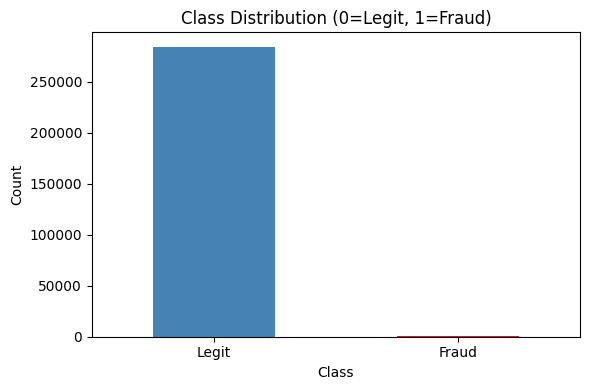

In [2]:
# Cell 2 — Class distribution
fig, ax = plt.subplots(figsize=(6, 4))
df['Class'].value_counts().plot(kind='bar', color=['steelblue', 'crimson'], ax=ax)
ax.set_title('Class Distribution (0=Legit, 1=Fraud)')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(['Legit', 'Fraud'], rotation=0)
plt.tight_layout()
plt.show()

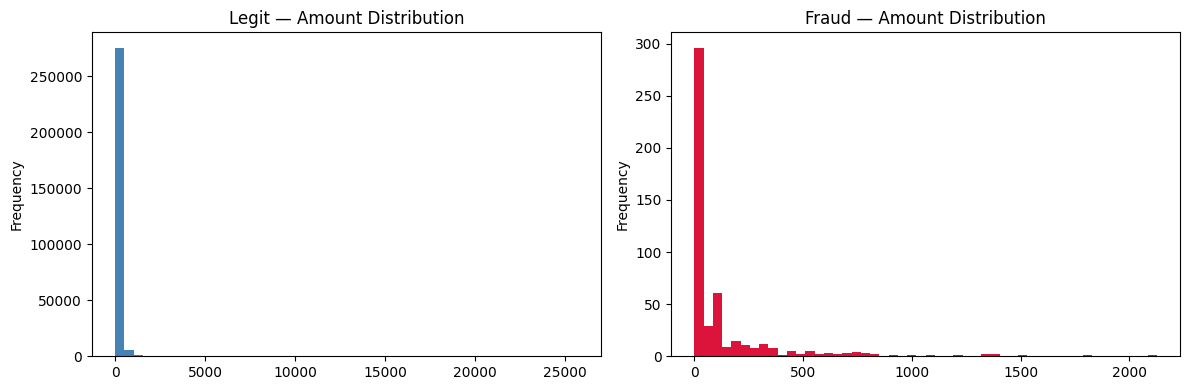

Avg legit amount:  $ 88.29
Avg fraud amount:  $ 122.21


In [3]:
# Cell 3 — Amount distribution by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['Class'] == 0]['Amount'].plot(
    kind='hist', bins=50, ax=axes[0],
    color='steelblue', title='Legit — Amount Distribution'
)
df[df['Class'] == 1]['Amount'].plot(
    kind='hist', bins=50, ax=axes[1],
    color='crimson', title='Fraud — Amount Distribution'
)
plt.tight_layout()
plt.show()

print("Avg legit amount:  $", round(df[df['Class']==0]['Amount'].mean(), 2))
print("Avg fraud amount:  $", round(df[df['Class']==1]['Amount'].mean(), 2))

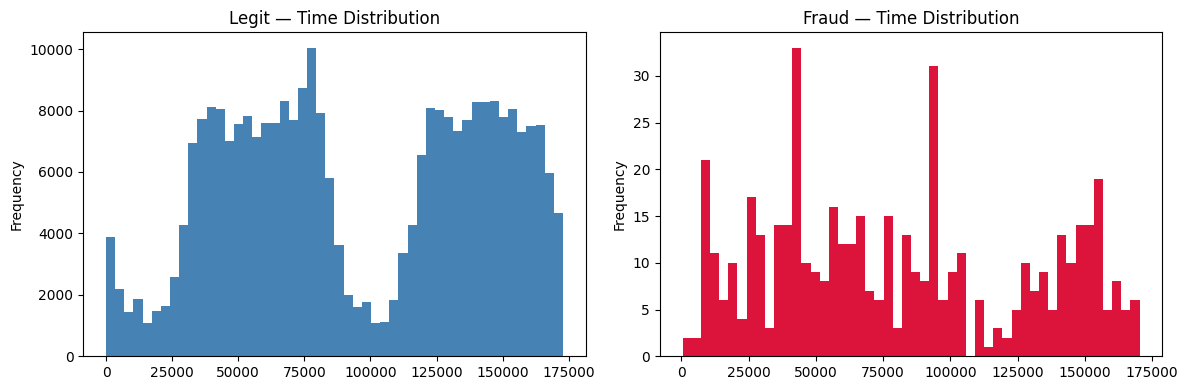

In [4]:
# Cell 4 — Transaction time by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['Class'] == 0]['Time'].plot(
    kind='hist', bins=50, ax=axes[0],
    color='steelblue', title='Legit — Time Distribution'
)
df[df['Class'] == 1]['Time'].plot(
    kind='hist', bins=50, ax=axes[1],
    color='crimson', title='Fraud — Time Distribution'
)
plt.tight_layout()
plt.show()

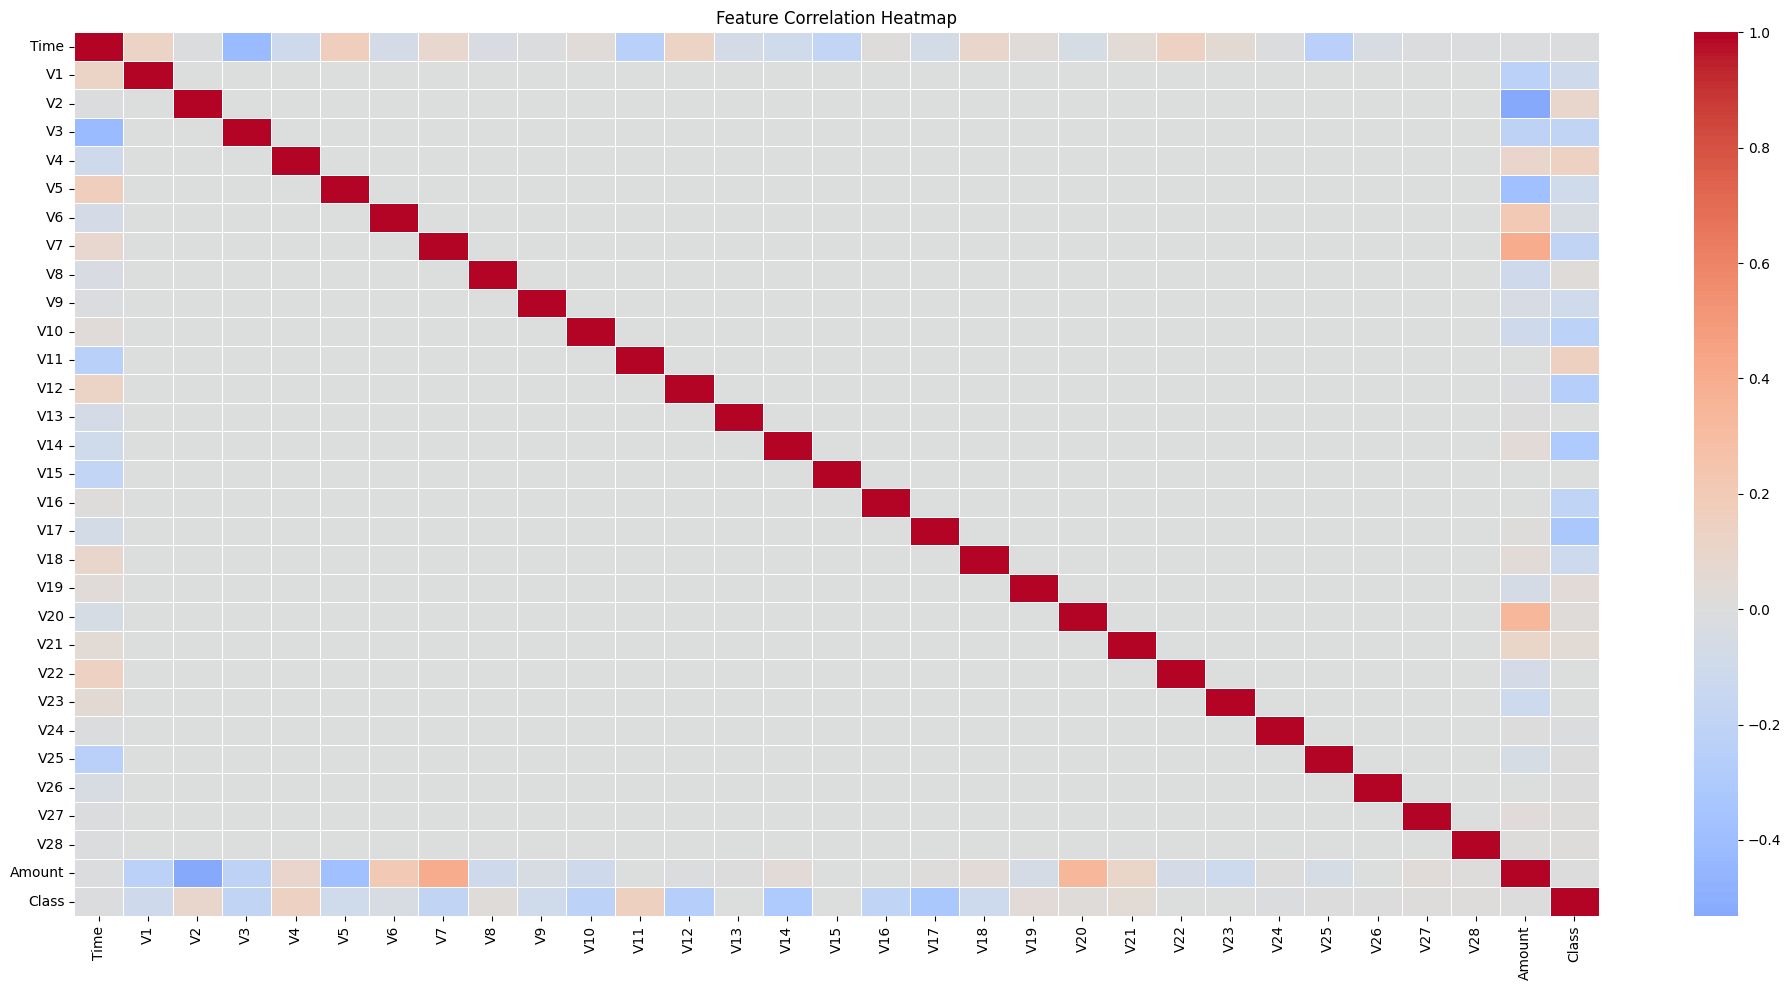

In [5]:
# Cell 5 — Correlation heatmap
plt.figure(figsize=(20, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [6]:
# Cell 6 — Top features correlated with fraud
fraud_corr = corr['Class'].drop('Class').sort_values(key=abs, ascending=False)
print("Top 10 features most correlated with fraud:\n")
print(fraud_corr.head(10))

Top 10 features most correlated with fraud:

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
Name: Class, dtype: float64


In [ ]:
# Cell 7 — Outliers in Amount
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['Class'] == 0].boxplot(column='Amount', ax=axes[0])
axes[0].set_title('Legit — Amount Outliers')

df[df['Class'] == 1].boxplot(column='Amount', ax=axes[1])
axes[1].set_title('Fraud — Amount Outliers')

plt.tight_layout()
plt.show()

print("Max legit amount:  $", df[df['Class']==0]['Amount'].max())
print("Max fraud amount:  $", df[df['Class']==1]['Amount'].max())